Exact period      = 2.374821
Estimated period  = 2.374667


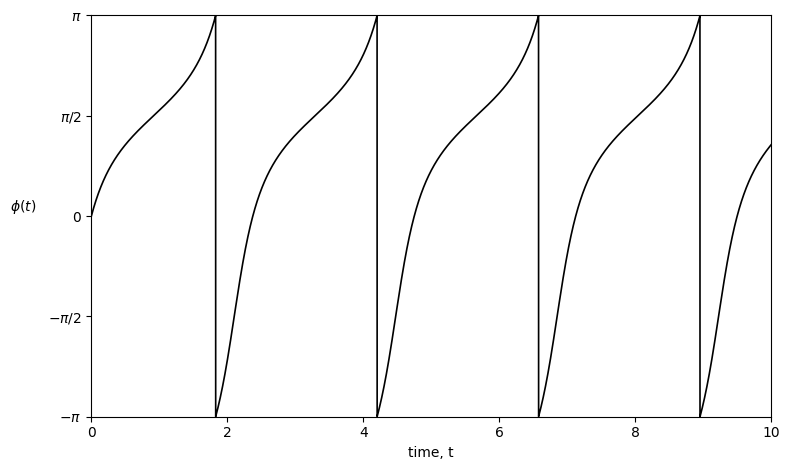

In [1]:
# ###########################################################################
# Author: Edward E. Daisey
# Course: Modeling & Simulation of Complex Systems
# Title: Assignment 9 - Problem 1(f)
# Date: 31st of March 2026
# ###########################################################################

################################### Overview ##################################
# Description:
#   This script simulates the phase-difference equation
#
#       phiDot = omega - K * sin(phi)
#
#   for the specific parameter values
#
#       omega = 4
#       K     = 3
#
#   using the classical fourth-order Runge-Kutta method (RK4). The script
#   wraps phi(t) into the interval (-pi, pi], produces a plot of phi(t), and
#   estimates the period from successive wrap crossings.
#
# Model:
#   phiDot = omega - K * sin(phi)
#
# Parameters:
#   omega = 4
#   K     = 3
#
# Initial Condition:
#   phi(0) = 0
#
# Time Interval:
#   t in [0, 10]
#
# Output:
#   (1) Plot of phi(t) wrapped to (-pi, pi]
#   (2) Estimated period from the numerical solution
#   (3) Exact period for comparison:
#
#       T = 2*pi / sqrt(omega^2 - K^2) = 2*pi / sqrt(7)
# ###########################################################################

# ############################ Imports ######################################
import math
import matplotlib.pyplot as plt
# ###########################################################################


# ############################ Constants ####################################
omega = 4.0
K = 3.0

initialPhi = 0.0

timeStart = 0.0
timeEnd = 10.0
timeStep = 0.001

exactPeriod = 2.0 * math.pi / math.sqrt(omega * omega - K * K)
# ###########################################################################


# ############################ Function 1 ###################################
# Name:
#   PhiVelocity
#
# Purpose:
#   Returns the time derivative for the phase-difference equation
#
#       phiDot = omega - K * sin(phi).
#
# Input:
#   phi : Current phase-difference.
#
# Output:
#   The derivative dphi/dt.
def PhiVelocity(phi):
    return omega - K * math.sin(phi)
# ###########################################################################


# ############################ Function 2 ###################################
# Name:
#   RungeKuttaStep
#
# Purpose:
#   Advances the phase-difference by one RK4 step.
#
# Input:
#   phi      : Current phase-difference.
#   stepSize : Time step.
#
# Output:
#   The updated phase-difference after one RK4 step.
def RungeKuttaStep(phi, stepSize):
    k1 = PhiVelocity(phi)
    k2 = PhiVelocity(phi + 0.5 * stepSize * k1)
    k3 = PhiVelocity(phi + 0.5 * stepSize * k2)
    k4 = PhiVelocity(phi + stepSize * k3)

    nextPhi = phi + (stepSize / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return nextPhi
# ###########################################################################


# ############################ Function 3 ###################################
# Name:
#   WrapToPi
#
# Purpose:
#   Wraps an angle into the interval (-pi, pi].
#
# Input:
#   phi : Phase-difference angle.
#
# Output:
#   Wrapped phase-difference.
def WrapToPi(phi):
    return ((phi + math.pi) % (2.0 * math.pi)) - math.pi
# ###########################################################################


# ############################ Function 4 ###################################
# Name:
#   SolveSystem
#
# Purpose:
#   Numerically solves the phase-difference equation on t in [0, 10], stores
#   the wrapped solution phi(t), and records wrap-crossing times for period
#   estimation.
#
# Input:
#   None.
#
# Output:
#   timeValues     : Sampled time points.
#   wrappedPhi     : Wrapped phase values in (-pi, pi].
#   crossingTimes  : Times at which phi wraps from near +pi to near -pi.
def SolveSystem():
    timeValues = []
    wrappedPhi = []
    crossingTimes = []

    currentTime = timeStart
    currentPhi = initialPhi
    previousWrappedPhi = WrapToPi(currentPhi)

    while currentTime <= timeEnd:
        currentWrappedPhi = WrapToPi(currentPhi)

        timeValues.append(currentTime)
        wrappedPhi.append(currentWrappedPhi)

        # Detect a wrap from near +pi to near -pi.
        if previousWrappedPhi > 2.0 and currentWrappedPhi < -2.0:
            crossingTimes.append(currentTime)

        previousWrappedPhi = currentWrappedPhi
        currentPhi = RungeKuttaStep(currentPhi, timeStep)
        currentTime += timeStep

    return timeValues, wrappedPhi, crossingTimes
# ###########################################################################


# ############################ Function 5 ###################################
# Name:
#   EstimatePeriod
#
# Purpose:
#   Estimates the period from successive wrap-crossing times.
#
# Input:
#   crossingTimes : Times at which phi wraps from near +pi to near -pi.
#
# Output:
#   Estimated period, or None if insufficient crossings are detected.
def EstimatePeriod(crossingTimes):
    if len(crossingTimes) < 2:
        return None

    periodSum = 0.0
    periodCount = 0

    for index in range(1, len(crossingTimes)):
        periodSum += crossingTimes[index] - crossingTimes[index - 1]
        periodCount += 1

    return periodSum / periodCount
# ###########################################################################


# ############################ Function 6 ###################################
# Name:
#   PlotSolution
#
# Purpose:
#   Plots the wrapped phase-difference phi(t) versus time.
#
# Input:
#   timeValues : Sampled time points.
#   wrappedPhi : Wrapped phase values.
#
# Output:
#   Displays the requested plot.
def PlotSolution(timeValues, wrappedPhi):
    plt.figure(figsize=(8, 4.8))
    plt.plot(timeValues, wrappedPhi, "k-", linewidth=1.2)
    plt.xlim(timeStart, timeEnd)
    plt.ylim(-math.pi, math.pi)
    plt.yticks(
        [-math.pi, -math.pi / 2.0, 0.0, math.pi / 2.0, math.pi],
        [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
    )
    plt.xlabel("time, t")
    plt.ylabel(r"$\phi(t)$", rotation=0, labelpad=18)
    plt.tight_layout()
    plt.show()
# ###########################################################################


# ############################ Function 7 ###################################
# Name:
#   Main
#
# Purpose:
#   Solves the phase-difference equation, estimates the period, prints the
#   numerical and exact period values, and displays the plot.
#
# Input:
#   None.
#
# Output:
#   Plot of phi(t) and printed period information.
def Main():
    timeValues, wrappedPhi, crossingTimes = SolveSystem()
    estimatedPeriod = EstimatePeriod(crossingTimes)

    print(f"Exact period      = {exactPeriod:.6f}")

    if estimatedPeriod is None:
        print("Estimated period  = not enough wrap crossings detected")
    else:
        print(f"Estimated period  = {estimatedPeriod:.6f}")

    PlotSolution(timeValues, wrappedPhi)
# ###########################################################################


# ############################# Execution ###################################
Main()
# ###########################################################################